In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from databricks import sql
from yfpy.query import YahooFantasySportsQuery
from dotenv import load_dotenv
from pathlib import Path

load_dotenv()

True

In [2]:
def clean_player_name(name):
    if name is None:
        return None

    # 1. Map common accented characters to normal ones
    accents = "āīūģķļņćčšžđáéíóúñçåøöäėëüĀĪŪĢĶĻŅĆČŠŽĐÁÉÍÓÚÑÇÅØÖÄĖËÜ"
    normals = "aiugklnccszdaeiouncaooaeeuAIUGKLNCCSZDAEIOUNCAOAAEEU"
    
    # Create a translation table
    trans_table = str.maketrans(accents, normals)
    name = name.translate(trans_table)

    # 2. Suffix removal
    # Using re.IGNORECASE makes it more robust than the Spark version
    suffix_pat = r"\s+(Jr\.?|Sr\.?|III|II|IV|V)$"
    name = re.sub(suffix_pat, "", name, flags=re.IGNORECASE)

    # 3. Non-alphanumeric cleaning
    # Note: the hyphen is placed at the end of the set to avoid being treated as a range
    char_pat = r"[^a-zA-Z0-9 '-]"
    name = re.sub(char_pat, "", name)

    # 4. Trim and return
    return name.strip()

In [9]:
with sql.connect(
    server_hostname=os.getenv("DATABRICKS_URL"),
    http_path=os.getenv("SQL_WAREHOUSE_HTTP_PATH"),
    access_token=os.getenv("BACKEND_TOKEN")
) as connection:
    with connection.cursor() as cursor:
        cursor.execute("SELECT * FROM nba_fantasy.gold.player_season_priors")
        arrow_table = cursor.fetchall_arrow()
        df_stats = arrow_table.to_pandas()

        cursor.execute("SELECT * FROM nba_fantasy.gold.nba_games_schedule")
        arrow_table = cursor.fetchall_arrow()
        df_schedule= arrow_table.to_pandas()

        cursor.execute("SELECT * FROM nba_fantasy.silver.nba_projections_weekly")
        arrow_table = cursor.fetchall_arrow()
        df_projections = arrow_table.to_pandas()

        cursor.execute("SELECT * FROM nba_fantasy.gold.ema")
        arrow_table = cursor.fetchall_arrow()
        df_ema = arrow_table.to_pandas()

In [12]:
df_ema

,PLAYER_ID,PLAYER_NAME,team,mu_min,mu_pts,var_pts,mu_reb,var_reb,mu_ast,var_ast,...,mu_fga,var_fga,mu_fgm,var_fgm,mu_fta,var_fta,mu_ftm,var_ftm,last_game_date,games_played


In [4]:
df_stats_current = df_stats[df_stats['SEASON_ID'] == "22025"]
df_stats_dict = df_stats_current.set_index('PLAYER_NAME').T.to_dict()

In [5]:
def is_this_week(schedule_date):
    start_of_week = pd.Timestamp("2026-03-16").normalize()
    schedule_date = pd.to_datetime(schedule_date).normalize()

    return start_of_week <= schedule_date < (start_of_week + pd.Timedelta(days=7))

df_schedule_week = df_schedule[df_schedule['scheduled_date'].apply(is_this_week)]

In [6]:
df_projections_dict = df_projections.set_index('player_name').T.to_dict()

In [8]:
auth_path = Path("../auth")
yahoo_query = YahooFantasySportsQuery(
    league_id="66811",
    game_code="nba",
    offline=False,
    yahoo_consumer_key=os.getenv("YAHOO_CONSUMER_KEY"),
    yahoo_consumer_secret=os.getenv("YAHOO_CONSUMER_SECRET"),
    env_file_location= auth_path,
    save_token_data_to_env_file=True
)

In [ ]:
team_info_3 = yahoo_query.get_team_info(3)
team_info_2 = yahoo_query.get_team_info(2)

2026-03-29 22:38:24.083 - WARNING - query.py - yfpy.query:1029 - No game id or season/year provided, defaulting to current fantasy season.
2026-03-29 22:38:25.530 - WARNING - query.py - yfpy.query:1029 - No game id or season/year provided, defaulting to current fantasy season.


In [ ]:
team_info_3._keys

['team_key',
 'team_id',
 'name',
 'is_owned_by_current_login',
 'url',
 'team_logos',
 'previous_season_team_rank',
 'division_id',
 'waiver_priority',
 'faab_balance',
 'number_of_moves',
 'number_of_trades',
 'roster_adds',
 'clinched_playoffs',
 'league_scoring_type',
 'has_draft_grade',
 'managers',
 'team_stats',
 'team_points',
 'team_standings',
 'roster',
 'draft_results',
 'matchups']

In [ ]:
team_info_3.roster.players[0]

Player({
  "display_position": "PG,SG,SF",
  "editorial_player_key": "nba.p.10108",
  "editorial_team_abbr": "HOU",
  "editorial_team_full_name": "Houston Rockets",
  "editorial_team_key": "nba.t.10",
  "editorial_team_url": "https://sports.yahoo.com/nba/teams/houston/",
  "eligible_positions": [
    "PG"
  ],
  "eligible_positions_to_add": [
    {
      "position": "PF"
    },
    {
      "position": "C"
    }
  ],
  "has_player_notes": 1,
  "headshot": {
    "size": "small",
    "url": "https://s.yimg.com/iu/api/res/1.2/VS._swpPaUA3AslGyj9ljQ--~C/YXBwaWQ9eXNwb3J0cztjaD0yMzM2O2NyPTE7Y3c9MTc5MDtkeD04NTc7ZHk9MDtmaT11bGNyb3A7aD02MDtxPTEwMDt3PTQ2/https://s.yimg.com/xe/i/us/sp/v/nba_cutout/players_l/11172025/10108.png"
  },
  "image_url": "https://s.yimg.com/iu/api/res/1.2/VS._swpPaUA3AslGyj9ljQ--~C/YXBwaWQ9eXNwb3J0cztjaD0yMzM2O2NyPTE7Y3c9MTc5MDtkeD04NTc7ZHk9MDtmaT11bGNyb3A7aD02MDtxPTEwMDt3PTQ2/https://s.yimg.com/xe/i/us/sp/v/nba_cutout/players_l/11172025/10108.png",
  "is_editable": 0,
  

In [ ]:
team_info_3.roster.players[0]._keys

['player_key',
 'player_id',
 'name',
 'url',
 'editorial_player_key',
 'editorial_team_key',
 'editorial_team_full_name',
 'editorial_team_abbr',
 'editorial_team_url',
 'is_keeper',
 'uniform_number',
 'display_position',
 'headshot',
 'image_url',
 'is_undroppable',
 'position_type',
 'primary_position',
 'eligible_positions',
 'eligible_positions_to_add',
 'has_player_notes',
 'player_notes_last_timestamp',
 'selected_position',
 'is_editable']

In [ ]:
categories = ["pts", "reb", "ast", "stl", "blk", "tov", "fg3m", "fga", "fgm", "fta", "ftm"]

stats = {}
for team_id in [3, 2]:
    stats[team_id] = {}
    for category in categories:
        stats[team_id][category] = {"mu": 0, "var": 0}

for team_id, team_info in [(3, team_info_3), (2, team_info_2)]:
    for player in team_info.roster.players:
        player_name = clean_player_name(player.full_name)
        team_abbr = player.editorial_team_abbr
        if not player.selected_position.position in ["IL", "IL+"]:
            num_games = len(df_schedule_week[df_schedule_week['team'] == team_abbr])
            for cat in categories:
                for i in range(num_games):
                    if cat in ["fga", "fgm", "fta", "ftm"]:
                        stats[team_id][cat]["mu"] += df_stats_dict[player_name][f"mu_{cat}"]
                    else:
                        stats[team_id][cat]["mu"] += float(df_projections_dict[player_name][f"mu_{cat}"])
                    stats[team_id][cat]["var"] += df_stats_dict[player_name][f"var_{cat}"]
        else:
            print(player_name, "is injured")
    
for team_id in [3, 2]:
    stats[team_id]["ft%"] = {"mu": stats[team_id]["ftm"]["mu"] / stats[team_id]["fta"]["mu"]}
    stats[team_id]["fg%"] = {"mu": stats[team_id]["fgm"]["mu"] / stats[team_id]["fga"]["mu"]}

Gary Payton is injured
Anthony Black is injured


In [ ]:
df_projections_dict

{'Shai Gilgeous-Alexander': {'GP': '4',
  'ingestion_timestamp': Timestamp('2026-03-26 01:43:47.588350+0000', tz='Etc/UTC'),
  'team': 'OKC',
  'position': 'PG',
  'mu_fg3m': 1.7999999523162842,
  'mu_ast': 6.5,
  'mu_blk': 0.800000011920929,
  'mu_fg_pct': 0.5339999794960022,
  'mu_ft_pct': 0.8840000033378601,
  'mu_min': 33.900001525878906,
  'mu_pts': 31.0,
  'mu_reb': 4.5,
  'mu_stl': 1.2999999523162842,
  'mu_tov': 2.0999999046325684},
 'Nikola Jokic': {'GP': '4',
  'ingestion_timestamp': Timestamp('2026-03-26 01:43:47.588350+0000', tz='Etc/UTC'),
  'team': 'DEN',
  'position': 'C',
  'mu_fg3m': 1.7999999523162842,
  'mu_ast': 10.699999809265137,
  'mu_blk': 0.800000011920929,
  'mu_fg_pct': 0.5809999704360962,
  'mu_ft_pct': 0.8259999752044678,
  'mu_min': 35.29999923706055,
  'mu_pts': 28.799999237060547,
  'mu_reb': 13.0,
  'mu_stl': 1.600000023841858,
  'mu_tov': 3.9000000953674316},
 'Kawhi Leonard': {'GP': '4',
  'ingestion_timestamp': Timestamp('2026-03-26 01:43:47.588350+0

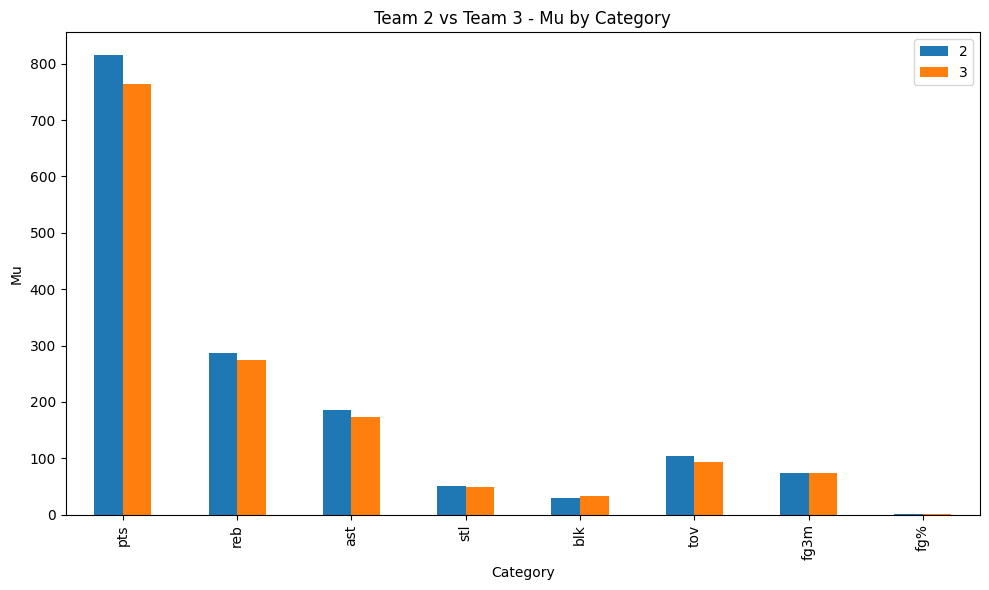

In [ ]:
plot_categories = ["pts", "reb", "ast", "stl", "blk", "tov", "fg3m", "fg%", "fg%"]

df_mu = pd.DataFrame({
    2: {cat: stats[2][cat]["mu"] for cat in plot_categories},
    3: {cat: stats[3][cat]["mu"] for cat in plot_categories},
})

ax = df_mu.plot(kind="bar", figsize=(10, 6))
ax.set_xlabel("Category")
ax.set_ylabel("Mu")
ax.set_title("Team 2 vs Team 3 - Mu by Category")
plt.tight_layout()

In [ ]:
stats

{3: {'pts': {'mu': 764.7000026702881, 'var': 2041.528611701072},
  'reb': {'mu': 274.5, 'var': 378.44679787163307},
  'ast': {'mu': 172.89999902248383, 'var': 204.44544396300674},
  'stl': {'mu': 49.09999978542328, 'var': 48.25317694683423},
  'blk': {'mu': 33.8000006377697, 'var': 33.45865840057059},
  'tov': {'mu': 93.6000007390976, 'var': 90.76101108864127},
  'fg3m': {'mu': 73.79999935626984, 'var': 85.98270212332277},
  'fga': {'mu': 565.2217761895125, 'var': 658.920367024467},
  'fgm': {'mu': 273.0355975385609, 'var': 292.23927904012186},
  'fta': {'mu': 178.88729439769241, 'var': 386.85340684103653},
  'ftm': {'mu': 139.15657181659358, 'var': 278.2484094225641},
  'ft%': {'mu': 0.7779008133871617},
  'fg%': {'mu': 0.483059232747988}},
 2: {'pts': {'mu': 814.9000039100647, 'var': 2281.555497302243},
  'reb': {'mu': 286.30000257492065, 'var': 459.3088939331722},
  'ast': {'mu': 185.89999902248383, 'var': 287.6338295189056},
  'stl': {'mu': 51.100000232458115, 'var': 57.66230340753

In [ ]:
def get_win_prob(mu1, var1, mu2, var2, lower_is_better=False):
    combined_sd = np.sqrt(var1 + var2)
    z = (mu1 - mu2) / combined_sd
    if lower_is_better:
        z = -z
    return norm.cdf(z)

# Data for Percentages
# We use 'mu' for p and 'fga/fta' for n to derive the variance
for pct_type, att_type in [('fg%', 'fga'), ('ft%', 'fta')]:
    for p_id in [2, 3]:
        p = stats[p_id][pct_type]['mu']
        n = stats[p_id][att_type]['mu']
        # Calculate variance of the proportion: p(1-p)/n
        stats[p_id][pct_type]['var'] = (p * (1 - p)) / n

# Compare them
categories = ['pts', 'reb', 'ast', 'stl', 'blk', 'tov', 'fg3m', 'fg%', 'ft%']

print(f"{'Category':<10} | {'P3 Win Prob':<12}")
print("-" * 25)

for cat in categories:
    p3_mu, p3_var = stats[3][cat]['mu'], stats[3][cat]['var']
    p2_mu, p2_var = stats[2][cat]['mu'], stats[2][cat]['var']
    
    prob = get_win_prob(p3_mu, p3_var, p2_mu, p2_var, lower_is_better=(cat == 'tov'))
    print(f"{cat:<10} | {prob:.2%}")

Category   | P3 Win Prob 
-------------------------
pts        | 22.26%
reb        | 34.18%
ast        | 27.89%
stl        | 42.30%
blk        | 72.93%
tov        | 77.35%
fg3m       | 49.69%
fg%        | 51.52%
ft%        | 19.04%
